In [ ]:
!pip install kaggle

In [ ]:
# configuring the path of kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

IMPORTING FACE MASK DATASET

In [ ]:
# API to fetch the dataset from kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:01<00:00, 152MB/s]



In [ ]:
from zipfile import ZipFile
dataset_path = '/content/face-mask-dataset.zip'
with ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall('/content/face-mask-dataset')
print('Extraction complete!')

Extraction complete!


IMPORTING THE DEPENDENCIES

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:
with_mask_file=os.listdir('/content/face-mask-dataset/data/with_mask')
print(with_mask_file[:5])
print(with_mask_file[-5:])

['with_mask_1314.jpg', 'with_mask_1848.jpg', 'with_mask_1728.jpg', 'with_mask_2291.jpg', 'with_mask_3081.jpg']
['with_mask_1285.jpg', 'with_mask_191.jpg', 'with_mask_2333.jpg', 'with_mask_1046.jpg', 'with_mask_300.jpg']


In [ ]:
without_mask_file=os.listdir('/content/face-mask-dataset/data/without_mask')
print(without_mask_file[:5])
print(without_mask_file[-5:])

['without_mask_1514.jpg', 'without_mask_2597.jpg', 'without_mask_1120.jpg', 'without_mask_2368.jpg', 'without_mask_1579.jpg']
['without_mask_1873.jpg', 'without_mask_1664.jpg', 'without_mask_1624.jpg', 'without_mask_3633.jpg', 'without_mask_1990.jpg']


In [ ]:
# len of with and without images
print("Number of images with mask",len(with_mask_file))
print("Number of images without mask",len(without_mask_file))

Number of images with mask 3725
Number of images without mask 3828


Creating Lables for the two class of images

with mask -> 1
without mask -> 0

In [ ]:
# create the lables

with_mask_labels=[1]*len(with_mask_file)
without_mask_labels=[0]*len(without_mask_file)

print(with_mask_labels[:5])
print(without_mask_labels[:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [ ]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [ ]:
labels=with_mask_labels+without_mask_labels
print(len(labels))
print(labels[:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


Displaying the images

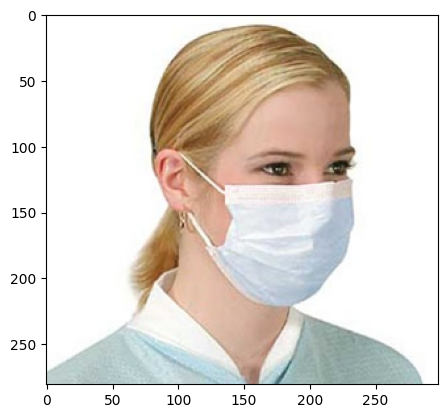

In [ ]:
# Displaying with mask image
img=mpimg.imread("/content/face-mask-dataset/data/with_mask/with_mask_3203.jpg") # read the img in numpy array
# print(img)
imgplot=plt.imshow(img)
plt.show()

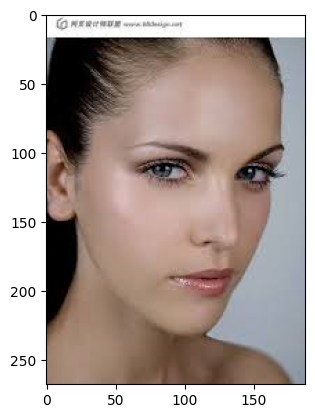

In [ ]:
# Displaying without mask image
img=mpimg.imread("/content/face-mask-dataset/data/without_mask/without_mask_607.jpg") # read the img in numpy array
# print(img)
imgplot=plt.imshow(img)
plt.show()

Image processing
1.convert images into numpy array
2.resize images

In [ ]:
with_mask_path="/content/face-mask-dataset/data/with_mask/"
data=[]
for img_file in with_mask_file:
  image=Image.open(with_mask_path+img_file)
  image=image.resize((128,128))
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)

without_mask_path="/content/face-mask-dataset/data/without_mask/"

for img_file in without_mask_file:
    image=Image.open(without_mask_path+img_file)
    image=image.resize((128,128))
    image=image.convert('RGB')
    image=np.array(image)
    data.append(image)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
type(data)

list

In [ ]:
type(data[0])

numpy.ndarray

In [ ]:
data[0].shape

(128, 128, 3)

Converting image list and labels list into numpy array

In [ ]:
x=np.array(data)
y=np.array(labels)

In [ ]:
# Shape of x and y
print(f"Shape of x is {x.shape} & shape of y is {y.shape}")

Shape of x is (7553, 128, 128, 3) & shape of y is (7553,)


Train Test Split

In [ ]:
x_train,x_temp,y_train,y_temp=train_test_split(x,y,test_size=0.3,random_state=1,stratify=y)
x_val,x_test,y_val,y_test=train_test_split(x_temp,y_temp,test_size=0.5,random_state=1)

print(f"shape of x_train is {x_train.shape}")
print(f"shape of x_test is {x_test.shape}")
print(f"shape of x_val is {x_val.shape}")
print(f"shape of y_train is {y_train.shape}")
print(f"shape of y_test is {y_test.shape}")
print(f"shape of y_val is {y_val.shape}")

shape of x_train is (5287, 128, 128, 3)
shape of x_test is (1133, 128, 128, 3)
shape of x_val is (1133, 128, 128, 3)
shape of y_train is (5287,)
shape of y_test is (1133,)
shape of y_val is (1133,)


In [ ]:
# # # Scaling the data
# x_train_scaled=x_train/255
# x_test_scaled=x_test/255

# # x_train_scaled[0]

Building a convolutional neural networks (CNN)

In [ ]:
import tensorflow as tf
# from tensorflow import keras
# from keras import Sequential
# from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Data Augmentation

Data augmentation is a technique used to increase the diversity of training data by applying random transformations to the images. This helps prevent overfitting and improves the model's ability to generalize to new, unseen data.

Here, we'll use `ImageDataGenerator` to apply transformations like rotation, zooming, width/height shifts, and horizontal flipping to our training images.

In [ ]:
# Create an ImageDataGenerator for data augmentation
train_data_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
train_data = train_data_gen.flow(
    x_train,
    y_train,
    batch_size=32
)

# print(train_data.class_indices)


In [ ]:
test_data_gen=ImageDataGenerator(rescale=1./255)


In [ ]:
test_data = test_data_gen.flow(
    x_test,
    y_test,
    batch_size=32
)

In [ ]:
val_data_gen=ImageDataGenerator(rescale=1./255)

In [ ]:
val_data=val_data_gen.flow(
    x_val,
    y_val,
    batch_size=32
)

In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile the neural network

In [ ]:
# from tensorflow.keras.optimizers import Adam
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

early_stop=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True,verbose=1)
lr_schedular=ReduceLROnPlateau(monitor='val_loss',factor=0.3,patience=2,verbose=1)

In [ ]:
# Training the neural network with augmented data
# We use the train_generator for training data and provide validation_data separately
# from the scaled test set. This is a common practice with ImageDataGenerator.

history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data, # Use the scaled test data for validation
    callbacks=[early_stop,lr_schedular]

)

Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 38s 178ms/step - accuracy: 0.7046 - loss: 1.5306 - val_accuracy: 0.5419 - val_loss: 1.4422 - learning_rate: 0.0010
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 24s 142ms/step - accuracy: 0.7443 - loss: 0.6899 - val_accuracy: 0.6152 - val_loss: 0.6570 - learning_rate: 0.0010
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 22s 132ms/step - accuracy: 0.7955 - loss: 0.5045 - val_accuracy: 0.8517 - val_loss: 0.3416 - learning_rate: 0.0010
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 23s 136ms/step - accuracy: 0.8182 - loss: 0.4392 - val_accuracy: 0.8959 - val_loss: 0.3645 - learning_rate: 0.0010
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 23s 139ms/step - accuracy: 0.8351 - loss: 0.4115 - val_accuracy: 0.8738 - val_loss: 0.2914 - learning_rate: 0.0010
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 23s 139ms/step - accuracy: 0.8417 - loss: 0.3946 - val_accuracy: 0.9126 - val_loss: 0.2599 - learning_rate: 0.0010
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 22s 135ms/step - accuracy: 0.8

Model Evaluation

In [ ]:
loss,accuracy=model.evaluate(test_data)
print("Test Accuracy",accuracy)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9718 - loss: 0.0983
Test Accuracy 0.9717563986778259


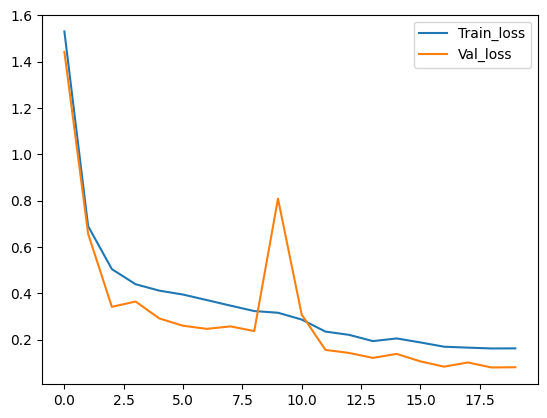

In [ ]:
plt.plot(history.history['loss'],label="Train_loss")
plt.plot(history.history['val_loss'],label="Val_loss")
plt.legend()
plt.show()

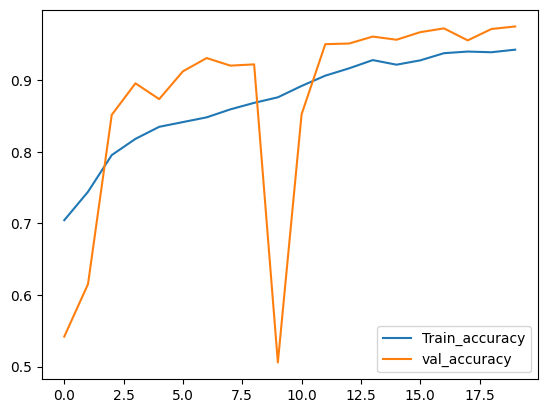

In [ ]:


# plot the loss value
plt.plot(history.history['accuracy'],label="Train_accuracy")
plt.plot(history.history['val_accuracy'],label="val_accuracy")
plt.legend()
plt.show()

Predictive system

Path of the image to be predicted (e.g., /content/face-mask-dataset/data/without_mask/without_mask_1464.jpg): /content/OIP (4).webp


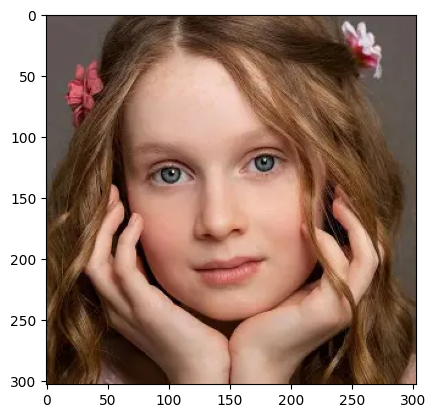

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediction value: 2.001469e-05
No Mask


In [ ]:
input_image_path=input("Path of the image to be predicted (e.g., /content/face-mask-dataset/data/without_mask/without_mask_1464.jpg): ")

input_image=cv2.imread(input_image_path) # by default imread BGR format mai read krta h


input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)  # FIX conversion BGR TO RGB

# cv2_imshow(input_image) # imshow bhi default mai BGR format mai show krta h isliye niche BLueish photo display hori h BGR mai
import matplotlib.pyplot as plt
plt.imshow(input_image)
plt.show()
cv2_image_resized = cv2.resize(input_image, (128,128))
input_image_scaled = cv2_image_resized / 255.0
input_image_reshaped = np.reshape(input_image_scaled, (1,128,128,3))

prediction = model.predict(input_image_reshaped)[0][0]

print("Prediction value:", prediction)

if prediction > 0.5:
    print("Mask")
else:
    print("No Mask")

In [ ]:
model.save("Face_mask.keras")


In [50]:
from google.colab import files

files.download('Face_mask.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>